<a href="https://colab.research.google.com/github/Nitin22122/DL-Lab/blob/main/Face_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/Dataset'

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 16
EPOCHS = 200

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    DATASET_PATH + "/Train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    DATASET_PATH + "/Test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 493 images belonging to 13 classes.
Found 144 images belonging to 13 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=test_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.1010 - loss: 2.6639 - val_accuracy: 0.1042 - val_loss: 2.5616
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.1119 - loss: 2.5621 - val_accuracy: 0.0694 - val_loss: 2.5206
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.1070 - loss: 2.5346 - val_accuracy: 0.2431 - val_loss: 2.3738
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.1708 - loss: 2.4203 - val_accuracy: 0.3333 - val_loss: 2.0327
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.2339 - loss: 2.2602 - val_accuracy: 0.4236 - val_loss: 1.8498
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.3069 - loss: 2.0221 - val_accuracy: 0.3333 - val_loss: 1.8723
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.2711 - loss: 2.0822 - val_accuracy: 0.4306 - val_loss: 1.7438
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.2861 - loss: 2.0654 - val_accur

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,918,953 (37.84 MB)

 Trainable params: 3,306,317 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,612,636 (25.23 MB)

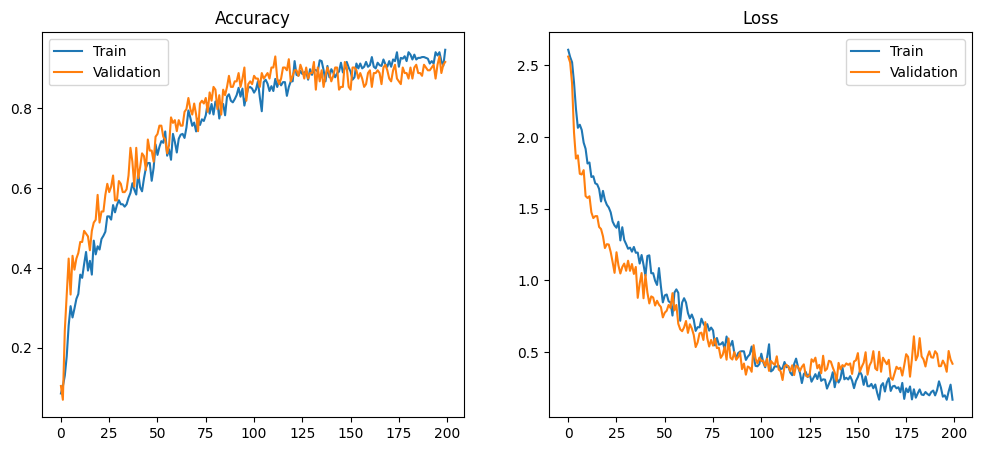

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image

img_path ='/content/drive/MyDrive/Dataset/Test/Alia Bhatt/Alia Bhatt_49.jpg'

In [ ]:
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
img = image.img_to_array(img)
img = img / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)
class_index = np.argmax(prediction)

labels = list(train_data.class_indices.keys())
print("Predicted Person:", labels[class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Predicted Person: Alia Bhatt


In [ ]:
model.save("/content/drive/MyDrive/face_recognition_cnn.h5")

In [ ]:
pred_probs = model.predict(test_data)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


In [ ]:
accuracy = np.mean(y_pred == y_true)
print("Test Accuracy:", accuracy * 100, "%")

Test Accuracy: 91.66666666666666 %


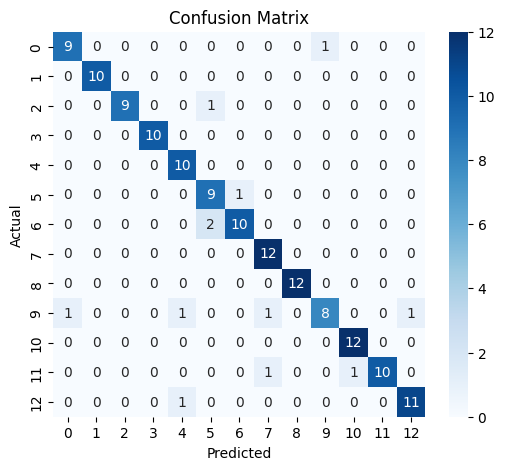


Classification Report:

                    precision    recall  f1-score   support

      Akshay Kumar       0.90      0.90      0.90        10
Alexandra Daddario       1.00      1.00      1.00        10
        Alia Bhatt       1.00      0.90      0.95        10
  Amitabh Bachchan       1.00      1.00      1.00        10
      Andy Samberg       0.83      1.00      0.91        10
    Anushka Sharma       0.75      0.90      0.82        10
   Priyanka Chopra       0.91      0.83      0.87        12
  Robert Downey Jr       0.86      1.00      0.92        12
     Roger Federer       1.00      1.00      1.00        12
        Tom Cruise       0.89      0.67      0.76        12
 Vijay Deverakonda       0.92      1.00      0.96        12
       Virat Kohli       1.00      0.83      0.91        12
         Zac Efron       0.92      0.92      0.92        12

          accuracy                           0.92       144
         macro avg       0.92      0.92      0.92       144
      weighte

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix with blue color
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))